---
# <Center>Initial Start

In [6]:
import os
import pandas as pd

# =========================================================
# 📁 PATH CONFIGURATION — แก้ที่นี่ที่เดียวถ้าต้องการเปลี่ยน path
# =========================================================
TRAIN_PATH  = os.path.join("Data", "Train_Data_1.csv")
TEST_PATH   = os.path.join("Data", "Test_Data_1.csv")
RESULT_PATH = "result"

# สร้างโฟลเดอร์ result (ครั้งเดียวตรงนี้ ไม่ต้องสร้างซ้ำในแต่ละ Cell)
os.makedirs(RESULT_PATH, exist_ok=True)

all_results = []
print("✅ Setup เรียบร้อย — TRAIN:", TRAIN_PATH, "| TEST:", TEST_PATH)


✅ Setup เรียบร้อย — TRAIN: Data\Train_Data_1.csv | TEST: Data\Test_Data_1.csv


---
# <Center>Proposed Method (DC-HKNN)

In [7]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import tracemalloc
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split # 🟢 เพิ่ม Library สำหรับแบ่งข้อมูล
from IPython.display import display

warnings.filterwarnings('ignore')

# =========================================================
# ⚙️ CONFIGURATION & PATH SETTINGS
# =========================================================
# TRAIN_PATH, TEST_PATH, RESULT_PATH กำหนดใน Cell 1 แล้ว

NO_SIGNAL = 100
REPLACE_RSSI = -90 
MIN_CLUSTER_SIZE = 2
EPS = 1e-6
MAX_VALID_RADIUS = 3.0
MIN_COVERAGE_TH = 0.80

K_FLOOR_LIST = list(range(1, 5))
K_POS_LIST   = list(range(15, 20))
RADIUS_LIST  = [35, 50, 65, 80] 
CONF_LIST    = [0.80, 0.90, 1.00]

# =========================================================
# 📂 1. LOAD DATA & SPLIT (Train / Validation / Test)
# =========================================================
train_full = pd.read_csv(TRAIN_PATH)
test_data  = pd.read_csv(TEST_PATH)

numeric_cols = train_full.select_dtypes(include=[np.number]).columns
rssi_cols = [c for c in numeric_cols if c not in ["X", "Y", "Z"]]

# 🟢 แบ่ง Train_Data ออกเป็น 80% Train และ 20% Validation
# ใช้ stratify เพื่อให้แน่ใจว่าได้ข้อมูลครบทุกชั้น
df_train, df_val = train_test_split(train_full, test_size=0.2, random_state=42, stratify=train_full['Z'])

# 1.1 ข้อมูลสำหรับสร้างแผนที่ (Train)
X_train  = df_train[rssi_cols].replace(NO_SIGNAL, REPLACE_RSSI).values
xy_train = df_train[["X", "Y"]].values
z_train  = df_train["Z"].values

# 1.2 ข้อมูลสำหรับทดสอบหา Parameter ในลูป (Validation)
X_val  = df_val[rssi_cols].replace(NO_SIGNAL, REPLACE_RSSI).values
xy_val = df_val[["X", "Y"]].values
z_val  = df_val["Z"].values

# 1.3 ข้อมูลสำหรับการทดสอบจริงรอบสุดท้าย (Test - ไม่นำไปยุ่งในลูป Grid Search เด็ดขาด!)
X_test  = test_data[rssi_cols].replace(NO_SIGNAL, REPLACE_RSSI).values
xy_test = test_data[["X", "Y"]].values
z_test  = test_data["Z"].values

# เตรียมข้อมูล Train แบบเต็มๆ ไว้ใช้สร้างโมเดลตอนจบ (รวม Train + Val กลับเข้าด้วยกัน)
Xtr_full = train_full[rssi_cols].replace(NO_SIGNAL, REPLACE_RSSI).values
xy_tr_full = train_full[["X", "Y"]].values
ytr_floor_full = train_full["Z"].values

# =========================================================
# 🔍 2. FULL GRID SEARCH (TRAINING & VALIDATION PHASE)
# =========================================================
best_score = 1e9
best_cfg = None

total_combinations = len(K_FLOOR_LIST) * len(K_POS_LIST) * len(RADIUS_LIST) * len(CONF_LIST)
print(f"🔍 Starting Grid Search (on Validation Set)... Total: {total_combinations}")
print("-" * 50)

tracemalloc.start()
start_total_train = time.perf_counter()
iteration_count = 0

for K_F in K_FLOOR_LIST:
    # 🟢 Fit ด้วย X_train, ทายผลด้วย X_val
    knn_floor = NearestNeighbors(n_neighbors=K_F, metric="euclidean")
    knn_floor.fit(X_train)
    _, idx_f = knn_floor.kneighbors(X_val)
    pred_floor = np.array([np.bincount(z_train[idx]).argmax() for idx in idx_f])

    for K_P in K_POS_LIST:
        for RADIUS in RADIUS_LIST:
            for CONF_TH in CONF_LIST:
                iteration_count += 1
                print(f"⏳ Grid Search {iteration_count}/{total_combinations} | KF:{K_F} KP:{K_P} Rad:{RADIUS} Conf:{CONF_TH}", end="\r")
                
                errors, accepted = [], 0

                for i in range(len(X_val)):
                    f = pred_floor[i]
                    mask = (z_train == f)
                    X_zone, xy_zone = X_train[mask], xy_train[mask]

                    if len(X_zone) >= K_P:
                        knn = NearestNeighbors(n_neighbors=K_P, metric="euclidean")
                        knn.fit(X_zone)
                        dist, idx = knn.kneighbors(X_val[i].reshape(1, -1))
                        dist, idx = dist.flatten(), idx.flatten()

                        if len(dist) > 1:
                            m_dist = np.mean(dist[1:])
                            conf = dist[0] / m_dist if m_dist > 0 else 0.0
                        else:
                            conf = 0.0 
                        
                        center_xy = xy_zone[idx[0]]
                        spatial_dist = np.linalg.norm(xy_zone[idx] - center_xy, axis=1)
                        radius_val = np.percentile(spatial_dist, RADIUS)
                        mc_mask = spatial_dist <= radius_val

                        if mc_mask.sum() >= MIN_CLUSTER_SIZE and (conf <= CONF_TH or radius_val <= MAX_VALID_RADIUS):
                            dist_mc, idx_mc = dist[mc_mask], idx[mc_mask]
                            weights = 1 / (dist_mc + EPS)
                            sum_weights = weights.sum()
                            if sum_weights > 0:
                                weights /= sum_weights
                                pred_xy = np.average(xy_zone[idx_mc], axis=0, weights=weights)
                                err_dist = np.linalg.norm(pred_xy - xy_val[i]) # 🟢 เทียบกับ xy_val
                                errors.append(err_dist)
                                accepted += 1

                if accepted < 10 or len(errors) == 0: 
                    continue
                
                coverage = accepted / len(X_val) # 🟢 หารด้วยจำนวน Validation Set
                if coverage < MIN_COVERAGE_TH:
                    continue
                    
                mean_err = np.mean(errors)
                score = mean_err + (1 - coverage) * 10.0 

                if score < best_score:
                    best_score = score
                    best_cfg = (K_F, K_P, RADIUS, CONF_TH)

# =========================================================
# 🥇 สร้าง FINAL MODEL จากชุดพารามิเตอร์ที่ดีที่สุด (ใช้ข้อมูล Train ทั้งหมด)
# =========================================================
if best_cfg:
    KF_B, KP_B, R_B, C_B = best_cfg
    # 🟢 ตอนนี้เราได้ Parameter ที่ดีที่สุดแล้ว เอามา Fit กับข้อมูล Training แบบเต็มๆ (Xtr_full)
    knn_floor_final = NearestNeighbors(n_neighbors=KF_B, metric="euclidean")
    knn_floor_final.fit(Xtr_full)
    
    floor_models = {}
    unique_floors = np.unique(ytr_floor_full)
    for f in unique_floors:
        mask = (ytr_floor_full == f)
        X_zone, xy_zone = Xtr_full[mask], xy_tr_full[mask]
        if len(X_zone) >= KP_B:
            knn_pos = NearestNeighbors(n_neighbors=KP_B, metric="euclidean")
            knn_pos.fit(X_zone)
            floor_models[f] = (knn_pos, xy_zone)

total_train_time = time.perf_counter() - start_total_train
print("\n" + "✅ Training & Validation Phase Completed! ".center(50, "="))

# =========================================================
# 🏆 3. PREDICTION PHASE (ทดสอบของจริงกับ Test Set ที่ปิดผนึกไว้!)
# =========================================================
if best_cfg:
    print("\n" + "🏆 BEST CONFIGURATION FOUND ".center(50, "="))
    print(f"K_FLOOR           : {KF_B}")
    print(f"K_POS             : {KP_B}")
    print(f"RADIUS (Percentile): {R_B}")
    print(f"CONF_THRESHOLD    : {C_B}")
    print("-" * 50)
    
    start_pred = time.perf_counter()
    
    # 🟢 ทายผลบน X_test ที่ไม่เคยเห็นมาก่อนเลย!
    _, idx_f = knn_floor_final.kneighbors(X_test)
    pred_floor = np.array([np.bincount(ytr_floor_full[idx]).argmax() for idx in idx_f])
    final_floor_acc = accuracy_score(z_test, pred_floor)
    
    final_errors = []
    final_predictions = []
    accepted_count = 0
    
    for i in range(len(X_test)):
        f = pred_floor[i]
        pred_x, pred_y = np.nan, np.nan
        err_dist = np.nan
        status = "Rejected"
        
        if f in floor_models:
            knn_pos, xy_zone = floor_models[f]
            dist, idx = knn_pos.kneighbors(X_test[i].reshape(1, -1))
            dist, idx = dist.flatten(), idx.flatten()
            
            if len(dist) > 1:
                m_dist = np.mean(dist[1:])
                conf = dist[0] / m_dist if m_dist > 0 else 0.0
            else:
                conf = 0.0
                
            center_xy = xy_zone[idx[0]]
            spatial_dist = np.linalg.norm(xy_zone[idx] - center_xy, axis=1)
            radius_val = np.percentile(spatial_dist, R_B)
            mc_mask = spatial_dist <= radius_val
            
            if mc_mask.sum() >= MIN_CLUSTER_SIZE and (conf <= C_B or radius_val <= MAX_VALID_RADIUS):
                dist_mc, idx_mc = dist[mc_mask], idx[mc_mask]
                weights = 1 / (dist_mc + EPS)
                sum_weights = weights.sum()
                if sum_weights > 0:
                    weights /= sum_weights
                    pred_xy = np.average(xy_zone[idx_mc], axis=0, weights=weights)
                    pred_x, pred_y = pred_xy[0], pred_xy[1]
                    err_dist = np.linalg.norm(pred_xy - xy_test[i])
                    
                    final_errors.append(err_dist)
                    accepted_count += 1
                    status = "Accepted"
        
        final_predictions.append({
            "Test_ID": i, "Actual_Z": z_test[i], "Pred_Z": f, "Floor_Correct": (z_test[i] == f),
            "Actual_X": xy_test[i][0], "Actual_Y": xy_test[i][1], "Pred_X": pred_x, "Pred_Y": pred_y,
            "Error_Distance": err_dist, "Status": status
        })
                    
    total_pred_time = time.perf_counter() - start_pred
    pred_time_per_sample = total_pred_time / len(X_test)
    
    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    memory_mb = peak_mem / (1024 * 1024)
    
    mde_final = np.mean(final_errors) if final_errors else 0.0
    final_coverage = accepted_count / len(X_test)

    # SD — Confidence Interval
    mde = np.mean(final_errors)
    std = np.std(final_errors)
    n = len(final_errors)
    ci_95 = 1.96 * std / np.sqrt(n)
    print(f"MDE: {mde:.3f} ± {std:.3f} m (95% CI: {mde-ci_95:.3f}–{mde+ci_95:.3f} m, n={n})")
    errors = np.array(final_errors)
    # print("=== Error Distribution Analysis ===")
    # print(f"MDE (Mean)     : {np.mean(errors):.3f} m")
    # print(f"Median         : {np.median(errors):.3f} m")
    # print(f"SD             : {np.std(errors):.3f} m")
    # print(f"Min            : {np.min(errors):.3f} m")
    # print(f"Max            : {np.max(errors):.3f} m")
    # print(f"P50            : {np.percentile(errors, 50):.3f} m")
    # print(f"P75            : {np.percentile(errors, 75):.3f} m")
    # print(f"P90            : {np.percentile(errors, 90):.3f} m")
    # print(f"P95            : {np.percentile(errors, 95):.3f} m")
    # print(f"Error <= 3m    : {(errors <= 3).mean()*100:.1f} %")
    # print(f"Error <= 5m    : {(errors <= 5).mean()*100:.1f} %")
    
    print(f"Floor Accuracy    : {final_floor_acc*100:.2f} %")
    print(f"Coverage          : {final_coverage*100:.2f} %")
    print("-" * 50)
    print("\n📊 CALCULATING PAPER METRICS (Strict ML Standard) 📊")
    print(f"Algorithm            : Proposed DC-Hierarchical KNN")
    print(f"MDE (meters)         : {mde_final:.3f}")
    print(f"Training Time (s)    : {total_train_time:.2f}") 
    print(f"Prediction Time (s)  : {pred_time_per_sample:.6f}") 
    print(f"Memory Usage (MB)    : {memory_mb:.2f}")
    print("=" * 50)
    
    df_results = pd.DataFrame(final_predictions)
    save_file = os.path.join(RESULT_PATH, "Proposed_Hierarchical_KNN.xlsx")
    df_results.to_excel(save_file, index=False)
    print(f"✅ Saved predictions to: {save_file}")

    # ✅ เก็บค่าลง all_results
    all_results.append({
        'Algorithm': 'Proposed Method (DC-HKNN)',
        'Floor Accuracy (%)': round(final_floor_acc * 100, 2),
        'MDE (meters)': round(mde_final, 3),
        'Training Time (s)': round(total_train_time, 2),
        'Prediction Time (s)': round(pred_time_per_sample, 6),
        'Memory Usage (MB)': round(memory_mb, 2)
    })
    print("✅ บันทึกค่าลง all_results เรียบร้อยแล้ว")
else:
    print("❌ Not found any configuration matching requirements.")

🔍 Starting Grid Search (on Validation Set)... Total: 240
--------------------------------------------------
⏳ Grid Search 240/240 | KF:4 KP:19 Rad:80 Conf:1.0
====✅ Training & Validation Phase Completed! =====

===========🏆 BEST CONFIGURATION FOUND ============
K_FLOOR           : 1
K_POS             : 16
RADIUS (Percentile): 35
CONF_THRESHOLD    : 1.0
--------------------------------------------------
MDE: 2.225 ± 3.133 m (95% CI: 2.039–2.410 m, n=1096)
Floor Accuracy    : 100.00 %
Coverage          : 100.00 %
--------------------------------------------------

📊 CALCULATING PAPER METRICS (Strict ML Standard) 📊
Algorithm            : Proposed DC-Hierarchical KNN
MDE (meters)         : 2.225
Training Time (s)    : 614.83
Prediction Time (s)  : 0.005820
Memory Usage (MB)    : 38.58
✅ Saved predictions to: result\Proposed_Hierarchical_KNN.xlsx
✅ บันทึกค่าลง all_results เรียบร้อยแล้ว


---
# <center>Hierarchical KNN

In [8]:
import pandas as pd
import numpy as np
import time
import tracemalloc
import os
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

# สร้างโฟลเดอร์ result หากยังไม่มี
# 1. โหลดข้อมูล
df = pd.read_csv(TRAIN_PATH)
DT = pd.read_csv(TEST_PATH)

# --- Clean Data: เปลี่ยนค่า 100 เป็น -90 ---
df.iloc[:, 1:19] = df.iloc[:, 1:19].replace(100, -90)
DT.iloc[:, 1:19] = DT.iloc[:, 1:19].replace(100, -90)

# กำหนด Features และ Target
X_train_raw = df.iloc[:, 1:19].values 
y_train_z = df['Z'].values           
y_train_xy = df[['X', 'Y']].values   

X_target_raw = DT.iloc[:, 1:19].values 
y_target_z = DT['Z'].values
y_target_xy = DT[['X', 'Y']].values

# --- Scaling ข้อมูล ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)       
X_target_scaled = scaler.transform(X_target_raw)

# [ปรับแก้] เริ่มจับ Memory ตรงนี้ (หลังจากโหลดไฟล์และเตรียมข้อมูลเสร็จ เพื่อวัดเฉพาะส่วนของ Algorithm)
tracemalloc.start()

# 2. กำหนด List ของ K ที่จะทดสอบ
K_FLOOR_LIST = list(range(1, 5))       
K_POS_LIST   = list(range(1, 25)) 

best_mde = float('inf')
best_result = {}
best_predictions = None

# คำนวณจำนวนคู่ Parameter ทั้งหมด
total_combinations = len(K_FLOOR_LIST) * len(K_POS_LIST)
current_iteration = 0

print("Training and evaluating Pure Mathematical Hierarchical KNN models...")
print(f"Total parameter combinations to test: {total_combinations} pairs\n")

# --- การปรับปรุงความเร็วตามหลักการในเปเปอร์ ---
# สร้างเมทริกซ์ระยะห่าง (Distance Matrix) แบบ Euclidean ล่วงหน้า
dist_matrix = cdist(X_target_scaled, X_train_scaled, metric='euclidean')

# เริ่มจับเวลา Training Time แบบรวมเวลา Hyperparameter Tuning ทั้งหมด
tuning_start_time = time.time()

# 3. วนลูปหา K_FLOOR และ K_POS ที่ดีที่สุด
for k_f in K_FLOOR_LIST:
    for k_p in K_POS_LIST:
        
        # นับจำนวนรอบและแสดงผล Real-time แบบพิมพ์ทับบรรทัดเดิม (บรรทัดเดียว)
        current_iteration += 1
        print(f"\r[{current_iteration}/{total_combinations}] Testing K_FLOOR={k_f}, K_POS={k_p} ...", end='', flush=True)
        
        # เริ่มจับเวลา Prediction Time สำหรับรอบนี้
        start_pred_time = time.time()
        
        # ตัวแปรเก็บผลลัพธ์การทำนาย
        pred_xy = np.zeros((len(X_target_scaled), 2))
        pred_floors = np.zeros(len(X_target_scaled))
        
        # --- Testing Phase: ทำนายผล "ทีละแถว (Row-by-Row)" ---
        for i in range(len(X_target_scaled)):
            
            # ดึงระยะห่างระหว่างจุด Test ที่ i กับจุด Train ทั้งหมด
            dists = dist_matrix[i]
            
            # === Step 1: ทำนาย Floor (KNN Classification) ===
            closest_kf_idx = np.argsort(dists)[:k_f]
            closest_floors = y_train_z[closest_kf_idx]
            
            unique_vals, counts = np.unique(closest_floors, return_counts=True)
            pred_floor = unique_vals[np.argmax(counts)]
            pred_floors[i] = pred_floor
            
            # === Step 2: ทำนายตำแหน่ง X, Y (KNN Regression) ===
            floor_mask = (y_train_z == pred_floor)
            floor_dists = dists[floor_mask]
            floor_xy = y_train_xy[floor_mask]
            
            if len(floor_dists) > 0:
                actual_k_p = min(k_p, len(floor_dists))
                closest_kp_idx = np.argsort(floor_dists)[:actual_k_p]
                
                top_dists = floor_dists[closest_kp_idx]
                top_xy = floor_xy[closest_kp_idx]
                
                weights = 1.0 / (top_dists + 1e-8) 
                pred_xy[i] = np.average(top_xy, axis=0, weights=weights)
            else:
                pred_xy[i] = [0, 0]
                
        end_pred_time = time.time()
        total_pred_time = end_pred_time - start_pred_time
        pred_time_per_sample = total_pred_time / len(X_target_scaled)
        
        # --- คำนวณ Error ---
        distances_2d = np.linalg.norm(y_target_xy - pred_xy, axis=1)
        mde_final = np.mean(distances_2d)
        floor_accuracy = np.mean(y_target_z == pred_floors) * 100
        
        # เก็บค่าที่ดีที่สุด (อิงจาก MDE ที่ต่ำที่สุด)
        if mde_final < best_mde:
            best_mde = mde_final
            best_result = {
                'K_Floor': k_f,
                'K_Pos': k_p,
                'Floor_Acc': floor_accuracy,
                'MDE': mde_final,
                'Pred_Time': pred_time_per_sample
            }
            best_predictions = np.column_stack((y_target_xy[:, 0], y_target_xy[:, 1], y_target_z, 
                                                pred_xy[:, 0], pred_xy[:, 1], pred_floors, distances_2d))

# พิมพ์ขึ้นบรรทัดใหม่หลังจากลูปทำงานเสร็จ
print("\n")

# หยุดจับเวลา Training Time รวม
tuning_end_time = time.time()
total_tuning_time = tuning_end_time - tuning_start_time

# [ปรับแก้] หยุดวัด Memory เช็คค่า Peak สูงสุดของทั้งกระบวนการ
current, peak = tracemalloc.get_traced_memory()
total_memory_mb = peak / (1024 * 1024)
tracemalloc.stop()

# 4. พิมพ์ผลลัพธ์ตาม Format ที่ต้องการ
print("="*50)
print("             Hierarchical KNN Results")
print("="*50)
print(f"Best K_FLOOR         : {best_result['K_Floor']}")
print(f"Best K_POS           : {best_result['K_Pos']}")
print("-" * 50)
print(f"Floor Accuracy (%)   : {best_result['Floor_Acc']:.2f}%")
print(f"MDE (meters)         : {best_result['MDE']:.3f}")
print(f"Training Time (s)    : {total_tuning_time:.2f}")        
print(f"Prediction Time (s)  : {best_result['Pred_Time']:.6f}")     
print(f"Memory Usage (MB)    : {total_memory_mb:.2f}") # โชว์ Memory รวมทั้งหมด
print("="*50)

# 5. เซฟผลลัพธ์ลง Excel
columns = ['Actual_X', 'Actual_Y', 'Actual_Floor', 'Pred_X', 'Pred_Y', 'Pred_Floor', 'Distance_Error_2D']
df_excel = pd.DataFrame(best_predictions, columns=columns)
save_path = os.path.join(RESULT_PATH, 'Hierarchical_KNN.xlsx')
df_excel.to_excel(save_path, index=False)
print(f"\n[INFO] Saved prediction vs actual results to '{save_path}'")

# ✅ เก็บค่าลง all_results
all_results.append({
    'Algorithm': 'Hierarchical KNN',
    'Floor Accuracy (%)': round(best_result['Floor_Acc'], 2),
    'MDE (meters)': round(best_result['MDE'], 3),
    'Training Time (s)': round(total_tuning_time, 2),
    'Prediction Time (s)': round(best_result['Pred_Time'], 6),
    'Memory Usage (MB)': round(total_memory_mb, 2)
})
print("✅ บันทึกค่าลง all_results เรียบร้อยแล้ว")


Training and evaluating Pure Mathematical Hierarchical KNN models...
Total parameter combinations to test: 96 pairs

[96/96] Testing K_FLOOR=4, K_POS=24 ...

             Hierarchical KNN Results
Best K_FLOOR         : 1
Best K_POS           : 20
--------------------------------------------------
Floor Accuracy (%)   : 99.64%
MDE (meters)         : 3.656
Training Time (s)    : 68.73
Prediction Time (s)  : 0.000506
Memory Usage (MB)    : 18.54

[INFO] Saved prediction vs actual results to 'result\Hierarchical_KNN.xlsx'
✅ บันทึกค่าลง all_results เรียบร้อยแล้ว


---
# <center>KNN

In [9]:
import pandas as pd
import numpy as np
import time
import tracemalloc
import os
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# สร้างโฟลเดอร์ result หากยังไม่มี
# 1. โหลดข้อมูล
df = pd.read_csv(TRAIN_PATH)
DT = pd.read_csv(TEST_PATH)

# --- [เทคนิคที่ 1] Clean Data: เปลี่ยนค่า 100 (No Signal) เป็น -90 ---
# เพราะ 100 คือ "ไม่มีสัญญาณ" ซึ่งไม่ใช่ค่า RSSI จริง
# ใช้ -90 เป็นค่าที่ต่ำกว่า RSSI ปกติ เพื่อสื่อว่าไม่มีสัญญาณ
df.iloc[:, 1:19] = df.iloc[:, 1:19].replace(100, -90)
DT.iloc[:, 1:19] = DT.iloc[:, 1:19].replace(100, -90)

X = df.iloc[:, 1:19].values 
y = df[['X', 'Y', 'Z']].values 
X_target = DT.iloc[:, 1:19].values 

# [เพิ่ม] เริ่มจับ Memory ตรงนี้ (หลังจากโหลดไฟล์เสร็จ)
tracemalloc.start()

# --- [เทคนิคที่ 2] Scaling ข้อมูล ---
# KNN แพ้เรื่อง Scale มาก ถ้าไม่ทำ Scale ค่า RSSI ที่แกว่งจะดึงระยะให้เพี้ยน
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)       # Fit และ Transform ข้อมูล Train
X_target_scaled = scaler.transform(X_target) # Transform ข้อมูล Test (ใช้ scale เดิม)

# แบ่ง Train/Test (ใช้ X_scaled แทน X ดิบ)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --- [เทคนิคที่ 3] จูน weights ---
# เพิ่ม weights: ['uniform', 'distance'] เข้าไป
# 'distance' จะช่วยให้จุดที่ RSSI ใกล้เคียงกันมากๆ มีน้ำหนักในการดึงกราฟมากกว่าจุดที่ไกล
cv = KFold(n_splits=10, random_state=1, shuffle=True)
grid_params_knn = {
    'n_neighbors': range(1, 25),
    'weights': ['uniform', 'distance'], 
    'metric': ['euclidean', 'manhattan'] # ลองเพิ่มระยะวัดแบบ Manhattan เผื่อเวิร์คกว่า
}

print("Start Training with GridSearchCV...")

# [เพิ่ม] เริ่มจับเวลา Training Time (รวมเวลา Hyperparameter Tuning)
tuning_start_time = time.time()

gs = GridSearchCV(KNeighborsRegressor(), grid_params_knn, cv=cv, n_jobs=-1)
gs.fit(X_train, y_train)

# [เพิ่ม] หยุดจับเวลา Training Time
tuning_end_time = time.time()
total_tuning_time = tuning_end_time - tuning_start_time

print(f"Best Parameters: {gs.best_params_}")

# สร้างโมเดลจากค่าที่ดีที่สุด
knn_final = KNeighborsRegressor(**gs.best_params_)
knn_final.fit(X_train, y_train)

# [เพิ่ม] เริ่มจับเวลา Prediction Time
pred_start_time = time.time()

# Predict (อย่าลืมใช้ X_target_scaled)
y_pred_target = knn_final.predict(X_target_scaled)

# [เพิ่ม] หยุดจับเวลา Prediction Time
pred_end_time = time.time()
pred_time_per_sample = (pred_end_time - pred_start_time) / len(X_target_scaled)

# [เพิ่ม] หยุดวัด Memory
current, peak = tracemalloc.get_traced_memory()
total_memory_mb = peak / (1024 * 1024)
tracemalloc.stop()

# Save ผลลัพธ์
coord_target = pd.DataFrame(y_pred_target, columns=['x_pred_', 'y_pred_', 'z_pred_'])
real_result = pd.concat([DT, coord_target], axis=1)

# คำนวณ Error ดั้งเดิมของคุณ (เป็นแบบ 3D)
actual_coords = DT[['X', 'Y', 'Z']].values
predicted_coords = y_pred_target
distances = np.linalg.norm(actual_coords - predicted_coords, axis=1)

mle = np.mean(distances)
accuracy_3m = np.mean(distances <= 3.0) * 100

print(f"Mean Location Error (MLE) : {mle:.4f} m")
print(f"Accuracy (< 3 meters)     : {accuracy_3m:.2f}%")

real_result['Error_Distance'] = distances
real_result.to_excel(os.path.join(RESULT_PATH, 'KNN.xlsx'), index=False)

# ==========================================================
# [เพิ่ม] คำนวณค่าเพิ่มเติมตามที่คุณต้องการ โดยไม่ต้องแก้ Logic ด้านบน
# ==========================================================
# 1. คำนวณ Floor Accuracy (แกน Z) โดยการปัดเศษทศนิยมที่ทำนายได้ให้เป็นจำนวนเต็มชั้น
pred_floors = np.round(predicted_coords[:, 2])
actual_floors = actual_coords[:, 2]
floor_accuracy = np.mean(pred_floors == actual_floors) * 100

# 2. คำนวณ MDE (Mean Distance Error) แบบ 2D เฉพาะแกน X, Y เหมือนโปรแกรมตัวก่อน
distances_2d = np.linalg.norm(actual_coords[:, :2] - predicted_coords[:, :2], axis=1)
mde_final = np.mean(distances_2d)

print("-" * 50)
print(f"Best K (Neighbors)   : {gs.best_params_['n_neighbors']}") 
print(f"Floor Accuracy (%)   : {floor_accuracy:.2f}%")
print(f"MDE (meters)         : {mde_final:.3f}")
print(f"Training Time (s)    : {total_tuning_time:.2f}")        
print(f"Prediction Time (s)  : {pred_time_per_sample:.6f}")     
print(f"Memory Usage (MB)    : {total_memory_mb:.2f}") 
print("-" * 50)

# ✅ เก็บค่าลง all_results
all_results.append({
    'Algorithm': 'KNN',
    'Floor Accuracy (%)': round(floor_accuracy, 2),
    'MDE (meters)': round(mde_final, 3),
    'Training Time (s)': round(total_tuning_time, 2),
    'Prediction Time (s)': round(pred_time_per_sample, 6),
    'Memory Usage (MB)': round(total_memory_mb, 2)
})
print("✅ บันทึกค่าลง all_results เรียบร้อยแล้ว")


Start Training with GridSearchCV...
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 12, 'weights': 'distance'}
Mean Location Error (MLE) : 3.8149 m
Accuracy (< 3 meters)     : 54.84%
--------------------------------------------------
Best K (Neighbors)   : 12
Floor Accuracy (%)   : 98.72%
MDE (meters)         : 3.814
Training Time (s)    : 13.39
Prediction Time (s)  : 0.000249
Memory Usage (MB)    : 2.79
--------------------------------------------------
✅ บันทึกค่าลง all_results เรียบร้อยแล้ว


---
# <center>Random Forrest

In [10]:
import pandas as pd
import numpy as np
import time
import tracemalloc
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import StandardScaler

# สร้างโฟลเดอร์ result หากยังไม่มี
# ==========================================
# 1. Load Data
# ==========================================
df = pd.read_csv(TRAIN_PATH)
DT = pd.read_csv(TEST_PATH)

# --- [แก้ไข] เปลี่ยนเป็น -110 ตามที่ตั้งใจไว้ ---
feature_cols = df.columns[1:19]
df[feature_cols] = df[feature_cols].replace(100, -110)
DT[feature_cols] = DT[feature_cols].replace(100, -110)

X = df.iloc[:, 1:19].values
y = df[['X', 'Y', 'Z']].values
X_target = DT.iloc[:, 1:19].values

# เริ่มจับ Memory (วัดเฉพาะ Algorithm)
tracemalloc.start()

# --- [แก้ไข] เปิดใช้งาน Scaler ---
# (การทำสเกลลิ่งทำให้โมเดลไม่ถูกตัวเลขค่ามาก-น้อยดึงน้ำหนักผิดเพี้ยน)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_target = scaler.transform(X_target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. GridSearch for Random Forest (เพิ่ม Parameter เยอะจัดเต็ม!)
# ==========================================
# ชุดพารามิเตอร์แบบอัดแน่น เพื่อสุ่มหาค่าที่ดีที่สุดแบบครอบคลุม
param_grid_rf = {
    'n_estimators': [200, 500, 800],           # จำนวนต้นไม้ (ป่าทึบขึ้น)
    'max_depth': [15, 25, 35, None],           # ความลึกสูงสุดของต้นไม้
    'min_samples_split': [2, 5, 10],           # จำนวน Data ขั้นต่ำที่ต้องมีเพื่อแตกกิ่ง
    'min_samples_leaf': [1, 2, 4],             # จำนวน Data ขั้นต่ำที่ต้องมีในโหนดใบ (ลด Overfitting)
    'max_features': ['sqrt', 0.5, 0.7, None],  # จำนวน Feature ที่ใช้สุ่ม (None = ใช้ 18 ต้น, 0.5 = ใช้ 9 ต้น)
    'bootstrap': [True, False]                 # สุ่มข้อมูลแบบใส่คืน/ไม่ใส่คืน
}

print("เริ่มเทรน Random Forest (ชุดนี้ Grid Search จัดเต็มมาก อาจใช้เวลา 5-10 นาที)...")
rf = RandomForestRegressor(random_state=42, n_jobs=-1) 
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# เริ่มจับเวลา Training Time
train_start_time = time.time()

gs_rf = GridSearchCV(rf, param_grid_rf, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
gs_rf.fit(X_train, y_train)

# ==========================================
# 3. Final Prediction
# ==========================================
best_rf = RandomForestRegressor(**gs_rf.best_params_, random_state=42, n_jobs=-1)
best_rf.fit(X, y) # Fit ข้อมูลทั้งหมดด้วยพารามิเตอร์ที่ดีที่สุด

# หยุดจับเวลา Training Time
train_end_time = time.time()
total_train_time = train_end_time - train_start_time

# เริ่มจับเวลา Prediction Time
pred_start_time = time.time()

y_pred_rf = best_rf.predict(X_target)

# หยุดจับเวลา Prediction Time
pred_end_time = time.time()
pred_time_per_sample = (pred_end_time - pred_start_time) / len(X_target)

# หยุดวัด Memory
current, peak = tracemalloc.get_traced_memory()
memory_mb = peak / (1024 * 1024)
tracemalloc.stop()

# ==========================================
# 4. Evaluation
# ==========================================
actual_coords = DT[['X', 'Y', 'Z']].values

# 1. คำนวณ Error แบบ 3D
distances_rf = np.linalg.norm(actual_coords - y_pred_rf, axis=1)
mle_rf = np.mean(distances_rf)
acc_3m = np.mean(distances_rf <= 3.0) * 100

# 2. คำนวณ Floor Accuracy (แกน Z)
pred_floors = np.round(y_pred_rf[:, 2])
actual_floors = actual_coords[:, 2]
floor_accuracy = np.mean(pred_floors == actual_floors) * 100

# 3. คำนวณ MDE (Mean Distance Error) แบบ 2D เฉพาะแกน X, Y
distances_2d = np.linalg.norm(actual_coords[:, :2] - y_pred_rf[:, :2], axis=1)
mde_final = np.mean(distances_2d)

# แสดงผล
print("-" * 50)
print("             Random Forest Results")
print("-" * 50)
print(f"Best Parameters      : {gs_rf.best_params_}")
print("-" * 50)
print(f"Floor Accuracy (%)   : {floor_accuracy:.2f}%")
print(f"MDE (meters)         : {mde_final:.3f}")
print(f"Training Time (s)    : {total_train_time:.2f}")        
print(f"Prediction Time (s)  : {pred_time_per_sample:.6f}")     
print(f"Memory Usage (MB)    : {memory_mb:.2f}")
print("-" * 50)

# Save
result = DT.copy()
result[['x_pred', 'y_pred', 'z_pred']] = y_pred_rf
result['Error_3D'] = distances_rf
result['Error_2D'] = distances_2d
rf_save_path = os.path.join(RESULT_PATH, 'RandomForest_Result.xlsx')
result.to_excel(rf_save_path, index=False)
print(f"\n[INFO] Saved result to '{rf_save_path}'")

# ✅ เก็บค่าลง all_results
all_results.append({
    'Algorithm': 'Random Forest',
    'Floor Accuracy (%)': round(floor_accuracy, 2),
    'MDE (meters)': round(mde_final, 3),
    'Training Time (s)': round(total_train_time, 2),
    'Prediction Time (s)': round(pred_time_per_sample, 6),
    'Memory Usage (MB)': round(memory_mb, 2)
})
print("✅ บันทึกค่าลง all_results เรียบร้อยแล้ว")


เริ่มเทรน Random Forest (ชุดนี้ Grid Search จัดเต็มมาก อาจใช้เวลา 5-10 นาที)...
--------------------------------------------------
             Random Forest Results
--------------------------------------------------
Best Parameters      : {'bootstrap': True, 'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
--------------------------------------------------
Floor Accuracy (%)   : 99.82%
MDE (meters)         : 3.774
Training Time (s)    : 1936.94
Prediction Time (s)  : 0.000270
Memory Usage (MB)    : 5.32
--------------------------------------------------

[INFO] Saved result to 'result\RandomForest_Result.xlsx'
✅ บันทึกค่าลง all_results เรียบร้อยแล้ว


---
# <center>XG Boost

In [11]:
import numpy as np
import pandas as pd
import xgboost as xgb
import time
import tracemalloc
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# =========================================================
# ⚙️ CONFIGURATION (ใช้ค่าดั้งเดิมของคุณทั้งหมด)
# =========================================================
TRAIN_BASE_PATH = TRAIN_PATH
DIRECTIONS = {
    # "West": "Data/West_radiomap.csv",
    # "East": "Data/East_radiomap.csv",
    # "North": "Data/North_radiomap.csv",
    # "South": "Data/South_radiomap.csv",
    "ALL": TEST_PATH 
}

NO_SIGNAL = 100
REPLACE_RSSI = -90 
GRID_SCALE = 1.0

def extract_features(df, rssi_cols):
    df = df.copy()
    temp_df = df[rssi_cols].replace(NO_SIGNAL, REPLACE_RSSI)
    df['rssi_max'] = temp_df.max(axis=1)
    df['rssi_mean'] = temp_df.mean(axis=1)
    df['rssi_std'] = temp_df.std(axis=1)
    
    sorted_vals = np.sort(temp_df.values, axis=1)
    df['top1_2_diff'] = sorted_vals[:, -1] - sorted_vals[:, -2]
    df['top1_3_diff'] = sorted_vals[:, -1] - sorted_vals[:, -3]
    
    for i in range(1, 6):
        df[f't{i}'] = sorted_vals[:, -i]
    return df

# =========================================================
# 📂 1. DATA PREPARATION
# =========================================================
print("🚀 Executing Heavy-Weight Training for Lower Error...")
train_base = pd.read_csv(TRAIN_BASE_PATH)
rssi_cols = [c for c in train_base.columns if 'RSSI' in c.upper()]

train_list = [train_base]
test_list = {}

for name, path in DIRECTIONS.items():
    df_raw = pd.read_csv(path)
    if name == "ALL":
        # --- OPTION 2: Hybrid Training (ดึง 50% มาช่วยเทรน) --- ตามโค้ดต้นฉบับ
        tr, te = train_test_split(df_raw, test_size=0.5, random_state=42, shuffle=True)
        train_list.append(tr)
        test_list[name] = te
    else:
        tr, te = train_test_split(df_raw, test_size=0.2, random_state=42, shuffle=True)
        train_list.append(tr)
        test_list[name] = te

train_all = pd.concat(train_list, axis=0).reset_index(drop=True)
train_all = extract_features(train_all, rssi_cols)

feature_cols = rssi_cols + ['rssi_max', 'rssi_mean', 'rssi_std', 'top1_2_diff', 'top1_3_diff', 't1', 't2', 't3', 't4', 't5']

le = LabelEncoder()
ytr_f_encoded = le.fit_transform(train_all["Z"].values)
xy_tr = train_all[["X", "Y"]].values

scaler = RobustScaler() 
Xtr = scaler.fit_transform(train_all[feature_cols])

# เริ่มจับเวลา Training และ Memory (ส่วนที่เพิ่มเข้ามา)
tracemalloc.start()
train_start_time = time.time()

# =========================================================
# 🚀 2. TRAINING
# =========================================================
clf_floor = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=8).fit(Xtr, ytr_f_encoded)

floor_models = {}
for f_idx in range(len(le.classes_)):
    mask_tr = (ytr_f_encoded == f_idx)
    if not any(mask_tr): continue
    
    reg = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=3000, 
        learning_rate=0.03, 
        max_depth=12, 
        subsample=0.9, 
        colsample_bytree=0.9,
        tree_method='hist'
    )
    floor_models[f_idx] = MultiOutputRegressor(reg).fit(Xtr[mask_tr], xy_tr[mask_tr])

# หยุดจับเวลา Training
train_end_time = time.time()
total_train_time = train_end_time - train_start_time

# =========================================================
# 📊 3. EVALUATION & EXPORT
# =========================================================
print("\n" + "="*65)
print(f"{'Direction':<12} | {'Floor Acc':<10} | {'Mean Err (m)':<15}")
print("-" * 65)

for name, test_df_raw in test_list.items():
    test_df_proc = extract_features(test_df_raw, rssi_cols)
    Xte = scaler.transform(test_df_proc[feature_cols])
    yte_f = test_df_proc["Z"].values
    xy_te = test_df_proc[["X", "Y"]].values

    # เริ่มจับเวลา Prediction
    pred_start_time = time.time()

    pred_f_enc = clf_floor.predict(Xte)
    pred_f_actual = le.inverse_transform(pred_f_enc)
    f_acc = accuracy_score(yte_f, pred_f_actual)

    final_preds = np.zeros((len(Xte), 2))
    for f_idx, model in floor_models.items():
        mask_te = (pred_f_enc == f_idx)
        if not any(mask_te): continue
        final_preds[mask_te] = model.predict(Xte[mask_te])

    # หยุดจับเวลา Prediction
    pred_end_time = time.time()
    pred_time_per_sample = (pred_end_time - pred_start_time) / len(Xte)

    err_m = np.linalg.norm(final_preds - xy_te, axis=1).mean() * GRID_SCALE
    
    # คำนวณ MDE เฉพาะแกน 2D (ที่เพิ่มเข้ามา)
    mde_final = np.linalg.norm(final_preds - xy_te, axis=1).mean() * GRID_SCALE
    floor_accuracy = f_acc * 100

    if name == "ALL": 
        print("-" * 65)
        # สร้าง DataFrame โดยดึงคอลัมน์ 'Index' จากไฟล์ต้นฉบับมาใช้โดยตรง
        export_df = pd.DataFrame({
            'Index': test_df_raw['Index'], # ดึงเลขกลุ่ม (1, 1, 1, 2, 2...)
            'X_true': xy_te[:, 0],
            'Y_true': xy_te[:, 1],
            'Z_true': yte_f,
            'X_pred': final_preds[:, 0],
            'Y_pred': final_preds[:, 1],
            'Z_pred': pred_f_actual
        })
        
        # เพิ่มคอลัมน์ Error รายจุด
        export_df['Error_m'] = np.linalg.norm(
            export_df[['X_true', 'Y_true']].values - export_df[['X_pred', 'Y_pred']].values, 
            axis=1
        ) * GRID_SCALE
        
        # เซฟไฟล์ Excel
        export_df.to_excel(os.path.join(RESULT_PATH, "XG_Boost.xlsx"), index=False)
        
    print(f"{name:<12} | {f_acc*100:>8.2f}% | {err_m:>12.3f} m")

# หยุดวัด Memory
current, peak = tracemalloc.get_traced_memory()
memory_mb = peak / (1024 * 1024)
tracemalloc.stop()

# พิมพ์ผลลัพธ์ในรูปแบบที่คุณต้องการ
print("="*65)
print("             XGBoost Final Results")
print("="*65)
print(f"Floor Accuracy (%)   : {floor_accuracy:.2f}%")
print(f"MDE (meters)         : {mde_final:.3f}")
print(f"Training Time (s)    : {total_train_time:.2f}")        
print(f"Prediction Time (s)  : {pred_time_per_sample:.6f}")     
print(f"Memory Usage (MB)    : {memory_mb:.2f}")
print("="*65)
print("\n✅ Exported 'XG_Boost.xlsx' .")

# ✅ เก็บค่าลง all_results
all_results.append({
    'Algorithm': 'XGBoost',
    'Floor Accuracy (%)': round(floor_accuracy, 2),
    'MDE (meters)': round(mde_final, 3),
    'Training Time (s)': round(total_train_time, 2),
    'Prediction Time (s)': round(pred_time_per_sample, 6),
    'Memory Usage (MB)': round(memory_mb, 2)
})
print("✅ บันทึกค่าลง all_results เรียบร้อยแล้ว")

🚀 Executing Heavy-Weight Training for Lower Error...

Direction    | Floor Acc  | Mean Err (m)   
-----------------------------------------------------------------
-----------------------------------------------------------------
ALL          |    99.82% |        3.279 m
             XGBoost Final Results
Floor Accuracy (%)   : 99.82%
MDE (meters)         : 3.279
Training Time (s)    : 58.95
Prediction Time (s)  : 0.000147
Memory Usage (MB)    : 43.53

✅ Exported 'XG_Boost.xlsx' .
✅ บันทึกค่าลง all_results เรียบร้อยแล้ว


---
# <center>Comparison of the Performance of Algorithms 


In [12]:
import pandas as pd
from IPython.display import display

# ✅ สร้างตารางเปรียบเทียบจาก all_results โดยอัตโนมัติ
df_compare = pd.DataFrame(all_results)

# จัดเรียงลำดับคอลัมน์ให้เหมือนตารางเดิม
col_order = ['Algorithm', 'Floor Accuracy (%)', 'MDE (meters)', 'Training Time (s)', 'Prediction Time (s)', 'Memory Usage (MB)']
df_compare = df_compare[col_order]

# แสดงผลแบบ Styled Table
display(
    df_compare.style
    .set_caption("Comparison of the Performance of Algorithms")
    .format({
        'Floor Accuracy (%)': '{:.2f}',
        'MDE (meters)': '{:.3f}',
        'Training Time (s)': '{:.2f}',
        'Prediction Time (s)': '{:.6f}',
        'Memory Usage (MB)': '{:.2f}'
    })
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#4472C4'), ('color', 'white')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
    ])
    .highlight_min(subset=['MDE (meters)', 'Training Time (s)', 'Prediction Time (s)', 'Memory Usage (MB)'], color='#C6EFCE')
    .highlight_max(subset=['Floor Accuracy (%)'], color='#C6EFCE')
)

# ✅ Export ตารางเปรียบเทียบออกเป็น Excel เพื่อใช้ทีหลัง
df_compare.to_excel(os.path.join(RESULT_PATH, 'comparison_table.xlsx'), index=False)
print(f"✅ Saved comparison table to '{os.path.join(RESULT_PATH, 'comparison_table.xlsx')}'")


,Algorithm,Floor Accuracy (%),MDE (meters),Training Time (s),Prediction Time (s),Memory Usage (MB)
0,Proposed Method (DC-HKNN),100.00,2.225,614.83,0.005820,38.58
1,Hierarchical KNN,99.64,3.656,68.73,0.000506,18.54
2,KNN,98.72,3.814,13.39,0.000249,2.79
3,Random Forest,99.82,3.774,1936.94,0.000270,5.32
4,XGBoost,99.82,3.279,58.95,0.000147,43.53


✅ Saved comparison table to 'result\comparison_table.xlsx'


---
# <center>CDF Graph

✅ โหลดและพล็อตข้อมูล 'Proposed (DC-Hierarchical KNN)' สำเร็จ
✅ โหลดและพล็อตข้อมูล 'Hierarchical KNN' สำเร็จ
✅ โหลดและพล็อตข้อมูล 'Standard KNN' สำเร็จ
✅ โหลดและพล็อตข้อมูล 'Random Forest' สำเร็จ
✅ โหลดและพล็อตข้อมูล 'XGBoost' สำเร็จ

📸 เซฟรูปกราฟเรียบร้อยแล้วที่ 'result\CDF Graph.png'


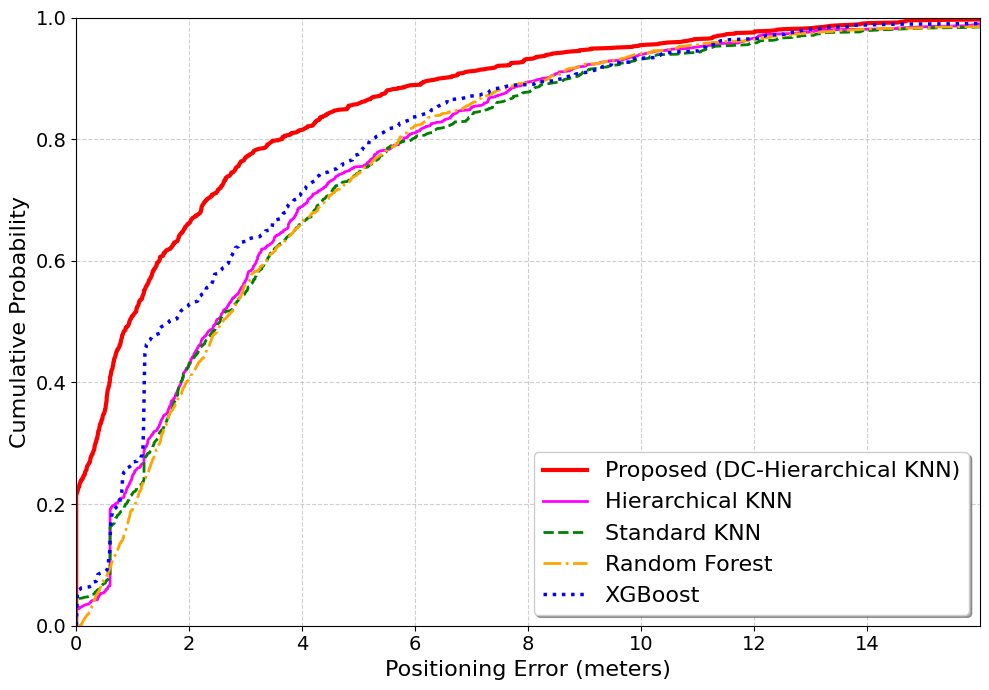

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# ⚙️ 1. ตั้งค่าไฟล์ผลลัพธ์ของแต่ละโมเดล
# ==========================================
# แก้ไข Path ให้ตรงกับที่คุณบันทึกไว้จริงๆ
models_config = {
    "Proposed (DC-Hierarchical KNN)": os.path.join(RESULT_PATH, "Proposed_Hierarchical_KNN.xlsx"),
    "Hierarchical KNN": os.path.join(RESULT_PATH, "Hierarchical_KNN.xlsx"),
    "Standard KNN": os.path.join(RESULT_PATH, "KNN.xlsx"),
    "Random Forest": os.path.join(RESULT_PATH, "RandomForest_Result.xlsx"),
    "XGBoost": os.path.join(RESULT_PATH, "XG_Boost.xlsx")
}

# กำหนดสีและรูปแบบเส้นให้แต่ละโมเดล
line_styles = {
    "Proposed (DC-Hierarchical KNN)": {"color": "red", "linestyle": "-", "linewidth": 3.0}, # เส้นหนาสีแดงเด่นๆ
    "Hierarchical KNN": {"color": "magenta", "linestyle": "-", "linewidth": 2.0},
    "Standard KNN": {"color": "green", "linestyle": "--", "linewidth": 2.0},
    "Random Forest": {"color": "orange", "linestyle": "-.", "linewidth": 2.0},
    "XGBoost": {"color": "blue", "linestyle": ":", "linewidth": 2.5}
}

# ==========================================
# 🔍 2. ฟังก์ชันสำหรับหาคอลัมน์ Error
# ==========================================
def get_error_column(df):
    """ฟังก์ชันช่วยหาว่าไฟล์นี้ตั้งชื่อคอลัมน์ Error ไว้ว่าอะไร"""
    # เรียงลำดับความสำคัญของชื่อคอลัมน์
    possible_names = ['Error_2D', 'Error_m', 'Error_Distance', 'Distance_Error_2D', 'Error']
    for col in possible_names:
        if col in df.columns:
            return df[col].values
    return None

# ==========================================
# 📊 3. โหลดข้อมูลและสร้างกราฟ
# ==========================================
plt.figure(figsize=(10, 7)) # ขนาดกราฟ (กว้าง 10, สูง 7)

# วนลูปอ่านไฟล์ของแต่ละโมเดลมาพล็อต
for model_name, file_path in models_config.items():
    if not os.path.exists(file_path):
        print(f"⚠️ ข้ามโมเดล '{model_name}': หาไฟล์ {file_path} ไม่พบ")
        continue
        
    try:
        # เช็คว่าเป็นไฟล์ CSV หรือ Excel แล้วโหลดข้อมูล
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            df = pd.read_excel(file_path)
            
        # ดึงข้อมูล Error ออกมา
        errors = get_error_column(df)
        
        if errors is not None and len(errors) > 0:
            # คำนวณ CDF
            sorted_errors = np.sort(errors)
            p = 1.0 * np.arange(len(sorted_errors)) / (len(sorted_errors) - 1)
            
            # วาดเส้นกราฟ
            style = line_styles.get(model_name, {"color": "black", "linestyle": "-", "linewidth": 2.0})
            plt.plot(sorted_errors, p, 
                     color=style['color'], 
                     linestyle=style['linestyle'], 
                     linewidth=style['linewidth'], 
                     label=model_name)
            
            print(f"✅ โหลดและพล็อตข้อมูล '{model_name}' สำเร็จ")
        else:
            print(f"❌ ข้ามโมเดล '{model_name}': ไม่พบคอลัมน์ Error ในไฟล์")
            
    except Exception as e:
            print(f"❌ เกิดข้อผิดพลาดในการอ่านไฟล์ '{model_name}': {e}")

# ==========================================
# 🎨 4. ตกแต่งกราฟสไตล์เปเปอร์วิจัย
# ==========================================
# นำ plt.title ออกตามที่ต้องการ
plt.xlabel('Positioning Error (meters)', fontsize=16)
plt.ylabel('Cumulative Probability', fontsize=16)

# กำหนดแกน X ให้อยู่ในช่วง 0 ถึง 12 เมตร และ Y 0 ถึง 1.0
plt.xlim(0, 16) 
plt.ylim(0, 1.0)

# ตั้งค่าแกน X ให้มีขีดบอกระยะ พร้อมปรับตัวเลขให้ใหญ่ขึ้น
plt.xticks(np.arange(0, 16, 2), fontsize=14) # ปรับให้ขีดห่างกันทุกๆ 2 เมตร
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14) # ปรับสเกลห่าง 0.2 (ใช้ 1.1 เพื่อให้วาดถึงเลข 1.0)

# ใส่เส้น Grid
plt.grid(True, linestyle='--', alpha=0.6)

# ปรับกรอบ Legend ให้ใหญ่ขึ้น (จากเดิม 12 เปลี่ยนเป็น 16)
plt.legend(loc='lower right', fontsize=16, frameon=True, shadow=True)

plt.tight_layout()

# เซฟกราฟออกมาเป็นรูปภาพระดับ HD ไว้ในโฟลเดอร์ result/
save_path = os.path.join(RESULT_PATH, 'CDF Graph.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n📸 เซฟรูปกราฟเรียบร้อยแล้วที่ '{save_path}'")

# แสดงกราฟบนหน้าจอ
plt.show()

# <center> Other Graph

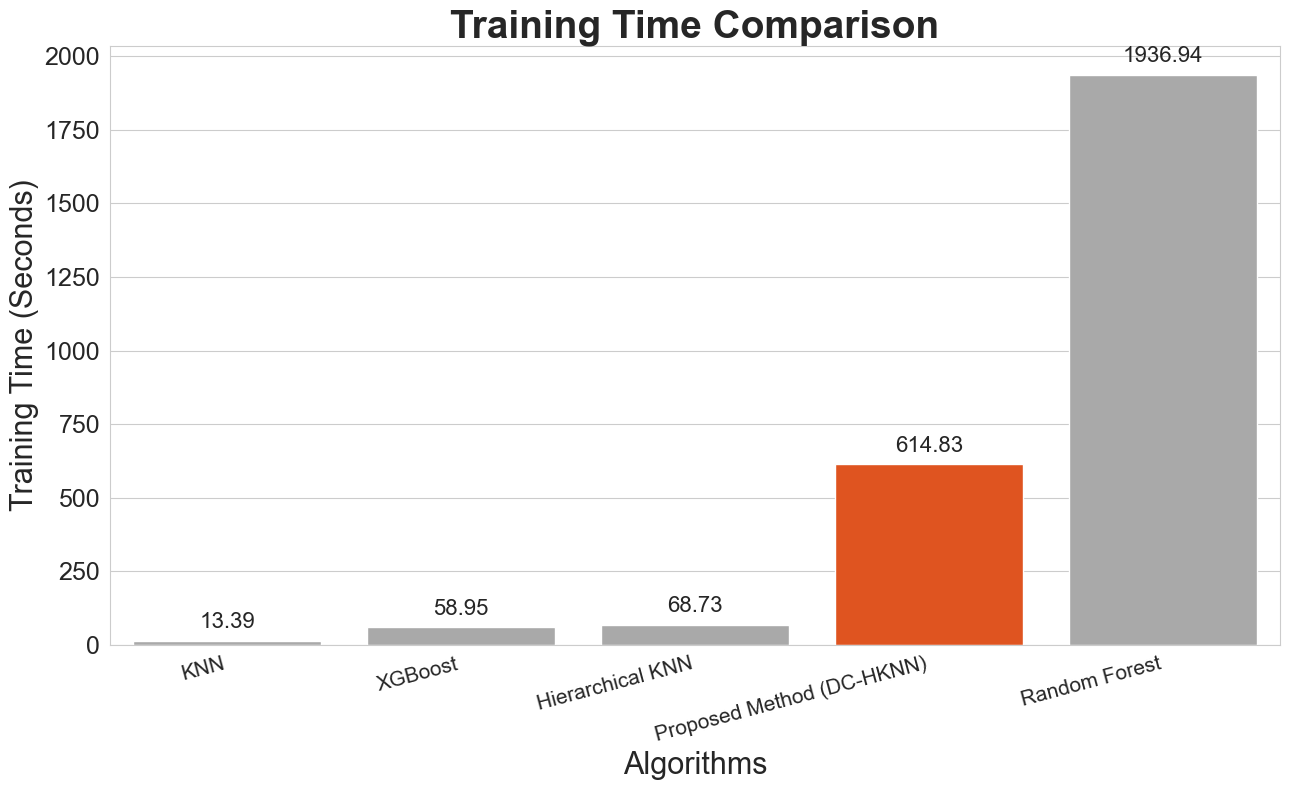

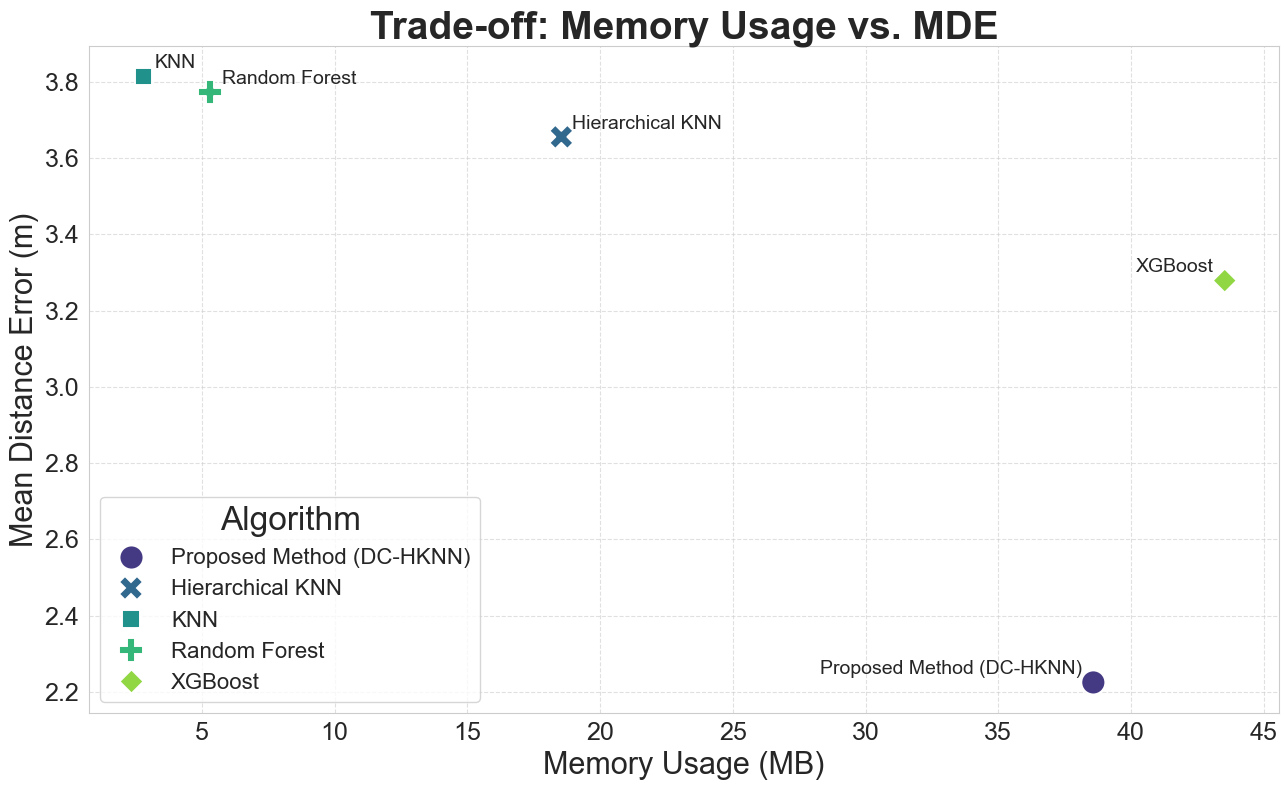

In [14]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ========================================================
# 2. วิธีที่ 2: ตั้งค่า Global Config (rcParams) ฉบับอัปเดต
# ========================================================
plt.rcParams.update({
    'axes.titlesize': 28,         # ขนาด Title ของกราฟ
    'axes.labelsize': 22,         # ขนาดหัวข้อแกน X และ Y
    'xtick.labelsize': 18,        # ขนาดตัวเลข/ตัวหนังสือบนแกน X
    'ytick.labelsize': 18,        # ขนาดตัวเลข/ตัวหนังสือบนแกน Y
    
    # --- ส่วนควบคุม Legend (แก้ตรงนี้!) ---
    'legend.fontsize': 16,        # ขนาดชื่อตัวลูก (KNN, XGBoost)
    'legend.title_fontsize': 24,  # <-- เพิ่มตรงนี้! ขยายขนาดหัวข้อ Legend (Algorithm)
    
    'font.weight': 'normal',      # ความหนาของฟอนต์ทั่วไป
    'axes.titleweight': 'bold'     # ความหนาของ Title
})

# ========================================================
# 3. เตรียมข้อมูล
# ========================================================
# ✅ ดึงข้อมูลจาก all_results โดยอัตโนมัติ
_df_raw = pd.DataFrame(all_results)
data = {
    'Algorithm': _df_raw['Algorithm'].tolist(),
    'Training Time (s)': _df_raw['Training Time (s)'].tolist(),
    'MDE (m)': _df_raw['MDE (meters)'].tolist(),
    'Memory Usage (MB)': _df_raw['Memory Usage (MB)'].tolist()
}

df = pd.DataFrame(data)

# ตั้งค่าสีตาม Algorithm name — ไม่ผูกกับลำดับใน list
# ทำให้ Proposed Method เด่นเสมอ ไม่ว่าจะ run ครบหรือไม่ครบก็ตาม
COLOR_MAP = {
    'Proposed Method (DC-HKNN)': '#FF4500',
}
DEFAULT_COLOR = '#A9A9A9'
colors = [COLOR_MAP.get(alg, DEFAULT_COLOR) for alg in df['Algorithm']]
sns.set_style("whitegrid")

# ========================================================
# 4. สร้างกราฟ
# ========================================================

# --- รูปที่ 1: Bar Chart สำหรับ Training Time ---
# เรียง DataFrame จากน้อยไปมากก่อน plot
df_sorted = df.sort_values('Training Time (s)').reset_index(drop=True)
colors_sorted = [COLOR_MAP.get(alg, DEFAULT_COLOR) for alg in df_sorted['Algorithm']]

fig, ax1 = plt.subplots(figsize=(13, 8))
sns.barplot(x='Algorithm', y='Training Time (s)', data=df_sorted, palette=colors_sorted, ax=ax1)

ax1.set_title('Training Time Comparison')
ax1.set_ylabel('Training Time (Seconds)')
ax1.set_xlabel('Algorithms')

# หมุน x-label และเพิ่ม padding ป้องกันตัวอักษรทับกัน
ax1.set_xticklabels(
    ax1.get_xticklabels(),
    rotation=15,
    ha='right',
    fontsize=15
)

# ใส่ตัวเลขกำกับบนแท่ง
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 6), textcoords='offset points', fontsize=16)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_PATH, 'training_time_comparison.png'), dpi=300)
plt.show()


# --- รูปที่ 2: Scatter Plot สำหรับ Memory Usage vs MDE ---
fig, ax2 = plt.subplots(figsize=(13, 8))
scatter = sns.scatterplot(x='Memory Usage (MB)', y='MDE (m)', hue='Algorithm',
                          style='Algorithm', data=df, s=300, palette='viridis', ax=ax2)

ax2.set_title('Trade-off: Memory Usage vs. MDE')
ax2.set_xlabel('Memory Usage (MB)')
ax2.set_ylabel('Mean Distance Error (m)')

# Label positioning: จุดที่อยู่ขวามาก (x > median) ให้ label ไปซ้าย ป้องกันทะลุกรอบ
x_vals = df['Memory Usage (MB)']
x_mid = x_vals.median()

for i in range(df.shape[0]):
    x = df['Memory Usage (MB)'].iloc[i]
    y = df['MDE (m)'].iloc[i]
    label = df['Algorithm'].iloc[i]

    if x > x_mid:
        # จุดฝั่งขวา → วาง label ไปทางซ้าย
        ax2.annotate(label, xy=(x, y),
                     xytext=(-8, 6), textcoords='offset points',
                     ha='right', fontsize=14)
    else:
        # จุดฝั่งซ้าย → วาง label ไปทางขวา
        ax2.annotate(label, xy=(x, y),
                     xytext=(8, 6), textcoords='offset points',
                     ha='left', fontsize=14)

ax2.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_PATH, 'memory_vs_mde_scatter.png'), dpi=300)
plt.show()